# Kiểm tra phân phối của Category và Label
Trực quan hóa và so sánh phân phối của dataset gốc so với các tập train/validate/test đã được split.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style cho biểu đồ
sns.set_theme(style="whitegrid")

In [5]:
# Đường dẫn tới các file dữ liệu
path_orig = '../processed/cleaned/Cleaned_Clickbait_Dataset.csv'
path_train = '../processed/cleaned/train_clean.csv'
path_val = '../processed/cleaned/validate_clean.csv'
path_test = '../processed/cleaned/test_clean.csv'

# Đọc dữ liệu
df_orig = pd.read_csv(path_orig)
df_train = pd.read_csv(path_train)
df_val = pd.read_csv(path_val)
df_test = pd.read_csv(path_test)

# Thêm cột 'Split' để phân biệt các tập dữ liệu
df_orig['Split'] = 'Original'
df_train['Split'] = 'Train'
df_val['Split'] = 'Validate'
df_test['Split'] = 'Test'

# Gộp dữ liệu lại để dễ dàng visualize bằng seaborn hue
df_all = pd.concat([df_orig, df_train, df_val, df_test], ignore_index=True)

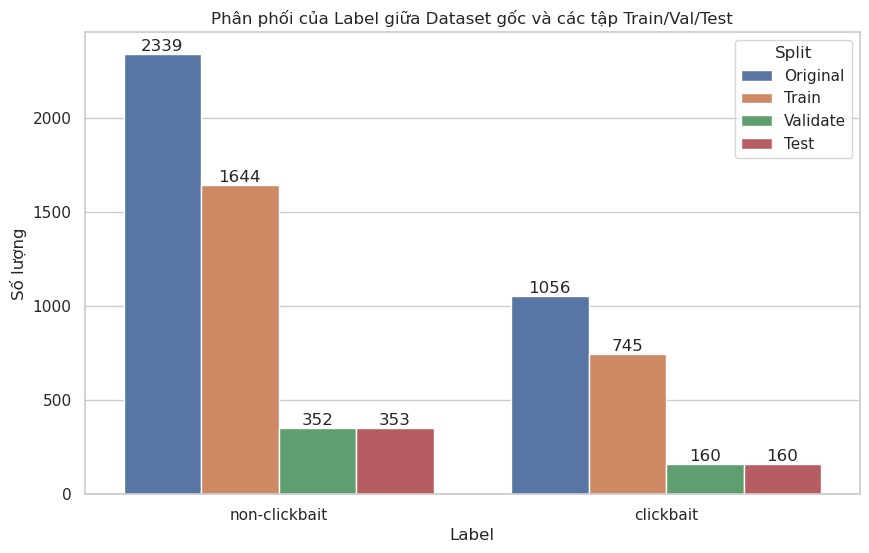

In [7]:
# 1. Visualize phân phối của Label
# Vẽ biểu đồ cột thẳng đứng cho label và hiển thị số lượng chính xác trên đầu mỗi cột
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_all, x='label', hue='Split')

# Thêm nhãn số lượng lên đầu mỗi cột
for container in ax.containers:
    ax.bar_label(container)

plt.title('Phân phối của Label giữa Dataset gốc và các tập Train/Val/Test')
plt.xlabel('Label')
plt.ylabel('Số lượng')
plt.show()

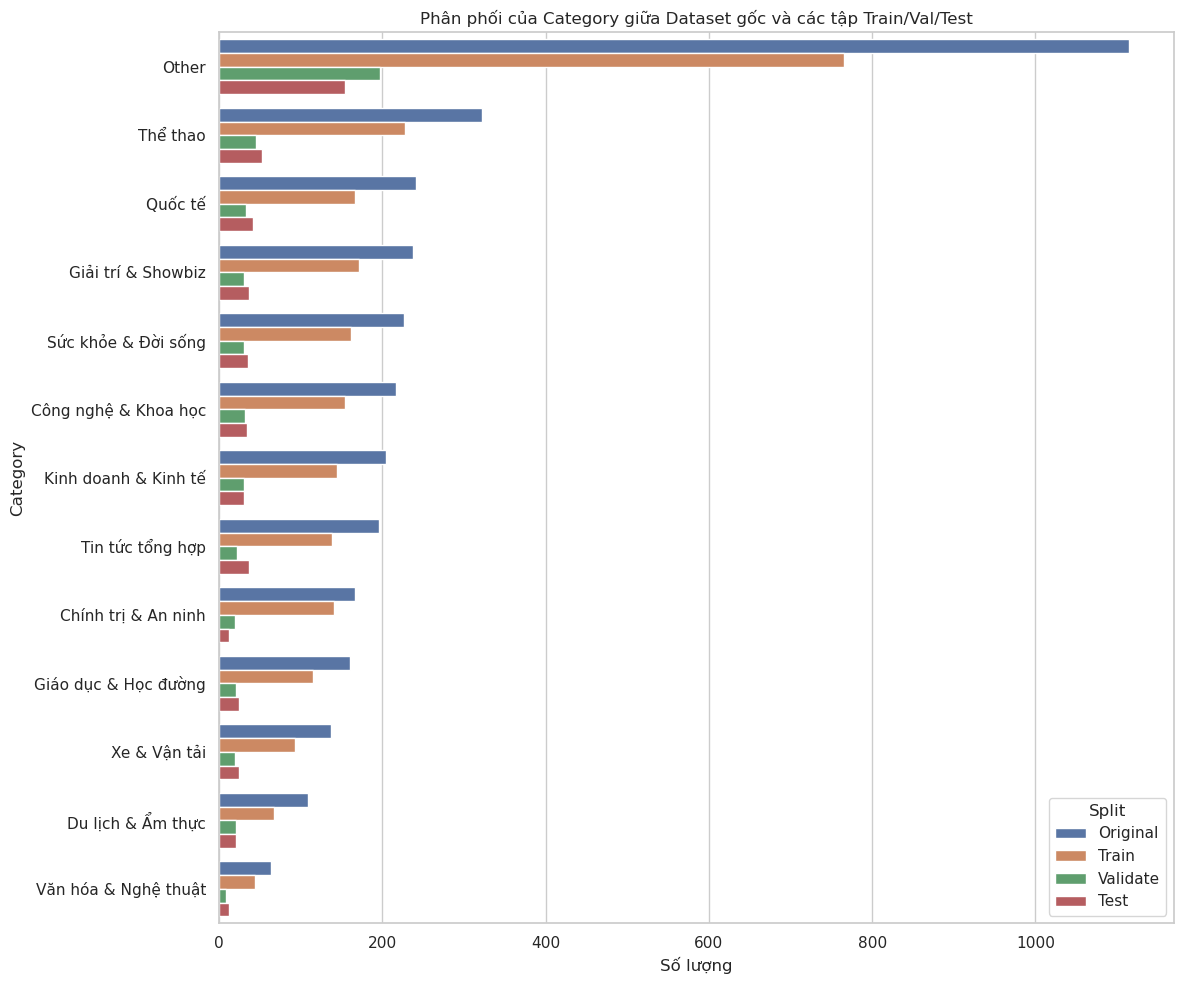

In [8]:
# 2. Visualize phân phối của Category
# Vì Category có nhiều giá trị, ta sử dụng biểu đồ thanh ngang (horizontal bar plot) để dễ đọc

plt.figure(figsize=(12, 10))
# Lấy danh sách category theo số lượng giảm dần từ dataset gốc để biểu đồ đẹp hơn
category_order = df_orig['category'].value_counts().index

sns.countplot(data=df_all, y='category', hue='Split', order=category_order)
plt.title('Phân phối của Category giữa Dataset gốc và các tập Train/Val/Test')
plt.xlabel('Số lượng')
plt.ylabel('Category')
plt.legend(title='Split', loc='lower right')
plt.tight_layout()
plt.show()

In [9]:
# 3. So sánh tỷ lệ (%) của từng Category giữa các tập dữ liệu
def get_percentage_df(df, name):
    counts = df['category'].value_counts(normalize=True).reset_index()
    counts.columns = ['category', f'{name} (%)']
    counts[f'{name} (%)'] = (counts[f'{name} (%)'] * 100).round(2)
    return counts

# Tính toán tỷ lệ cho từng tập
pct_orig = get_percentage_df(df_orig, 'Original')
pct_train = get_percentage_df(df_train, 'Train')
pct_val = get_percentage_df(df_val, 'Validate')
pct_test = get_percentage_df(df_test, 'Test')

# Merge các dataframe lại để so sánh
comparison_df = pct_orig.merge(pct_train, on='category', how='outer')\
                          .merge(pct_val, on='category', how='outer')\
                          .merge(pct_test, on='category', how='outer')

# Hiển thị bảng so sánh
print("Bảng so sánh tỷ lệ (%) của Category giữa các dataset:")
display(comparison_df.sort_values(by='Original (%)', ascending=False))

Bảng so sánh tỷ lệ (%) của Category giữa các dataset:


,category,Original (%),Train (%),Validate (%),Test (%)
6,Other,32.81,32.06,38.48,30.02
9,Thể thao,9.48,9.54,8.79,10.14
7,Quốc tế,7.10,6.95,6.45,8.19
4,Giải trí & Showbiz,7.01,7.16,6.05,7.02
8,Sức khỏe & Đời sống,6.69,6.78,6.05,6.82
1,Công nghệ & Khoa học,6.39,6.45,6.25,6.63
5,Kinh doanh & Kinh tế,6.01,6.03,5.86,5.85
10,Tin tức tổng hợp,5.77,5.78,4.30,7.21
0,Chính trị & An ninh,4.92,5.90,3.91,2.34
3,Giáo dục & Học đường,4.71,4.81,4.10,4.68


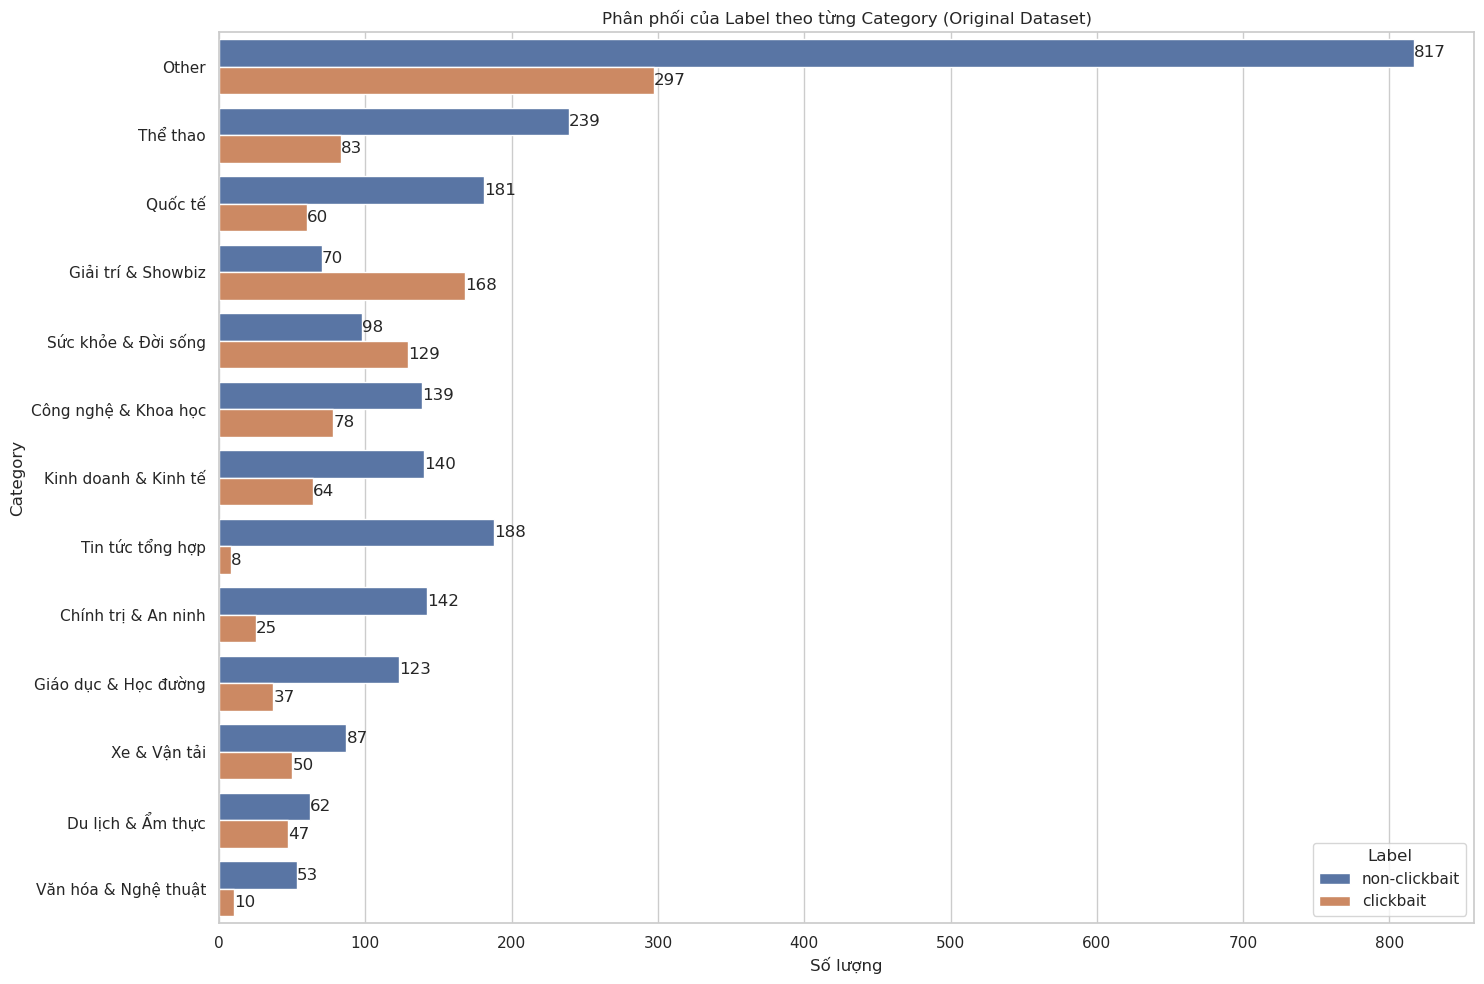

Tỷ lệ % Label trong từng Category:


,Label clickbait (%),Label non-clickbait (%)
category,,
Other,26.66,73.34
Thể thao,25.78,74.22
Quốc tế,24.90,75.10
Giải trí & Showbiz,70.59,29.41
Sức khỏe & Đời sống,56.83,43.17
Công nghệ & Khoa học,35.94,64.06
Kinh doanh & Kinh tế,31.37,68.63
Tin tức tổng hợp,4.08,95.92
Chính trị & An ninh,14.97,85.03


In [10]:
# 4. Phân phối Label theo từng nhóm Category (Original Dataset)
plt.figure(figsize=(15, 10))

# Vẽ biểu đồ cột chồng (stacked bar) hoặc grouped bar để xem phân phối label trong mỗi category
ax = sns.countplot(data=df_orig, y='category', hue='label', order=category_order)

# Thêm nhãn số lượng
for container in ax.containers:
    ax.bar_label(container)

plt.title('Phân phối của Label theo từng Category (Original Dataset)')
plt.xlabel('Số lượng')
plt.ylabel('Category')
plt.legend(title='Label', loc='lower right')
plt.tight_layout()
plt.show()

# Xuất bảng thống kê chi tiết
label_dist_by_cat = pd.crosstab(df_orig['category'], df_orig['label'], normalize='index') * 100
label_dist_by_cat = label_dist_by_cat.round(2)
label_dist_by_cat.columns = [f'Label {col} (%)' for col in label_dist_by_cat.columns]

print("Tỷ lệ % Label trong từng Category:")
display(label_dist_by_cat.loc[category_order])

In [11]:
# 5. Phân chia lại dữ liệu và lưu id (Stratify theo Label và Category)
from sklearn.model_selection import train_test_split
import os
import json

# Thư mục lưu kết quả
os.makedirs('../test_data', exist_ok=True)

# Tạo cột gộp label và category để stratify
df_orig['stratify_col'] = df_orig['label'].astype(str) + '_' + df_orig['category'].astype(str)

# Chia Train (70%) và Temp (30%)
train_df, temp_df = train_test_split(df_orig, test_size=0.3, random_state=42, stratify=df_orig['stratify_col'])

# Chia Temp thành Validate (15%) và Test (15%)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['stratify_col'])

# Tạo JSON dictionary chứa list id
split_ids = {
    'train': train_df['id'].tolist(),
    'validate': val_df['id'].tolist(),
    'test': test_df['id'].tolist()
}

with open('../test_data/split_ids.json', 'w') as f:
    json.dump(split_ids, f, indent=4)

print("Đã lưu id của từng tập vào file: 'data/test_data/split_ids.json'")
print(f"Số lượng Train: {len(train_df)}, Validate: {len(val_df)}, Test: {len(test_df)}")

# Xóa cột phụ
df_orig.drop(columns=['stratify_col'], inplace=True)

Đã lưu id của từng tập vào file: 'data/test_data/split_ids.json'
Số lượng Train: 2376, Validate: 509, Test: 510
